# Triage hand-off: 언어별 전문 Agent

**대상:** Python 함수와 async/await에 익숙한 Agent 입문자.

**학습 목표:** 언어 분류 → 전문 Agent로 위임 → 응답 과정을 Agent 정의와 실행 셀로 직접 구성합니다.

**순서:** 환경 준비 → 입력·Agent 정의 → 실행 → 결과 확인 → 작은 실습.

소스 코드 · 예제 안내 · 환경 설정

### 패턴 구조

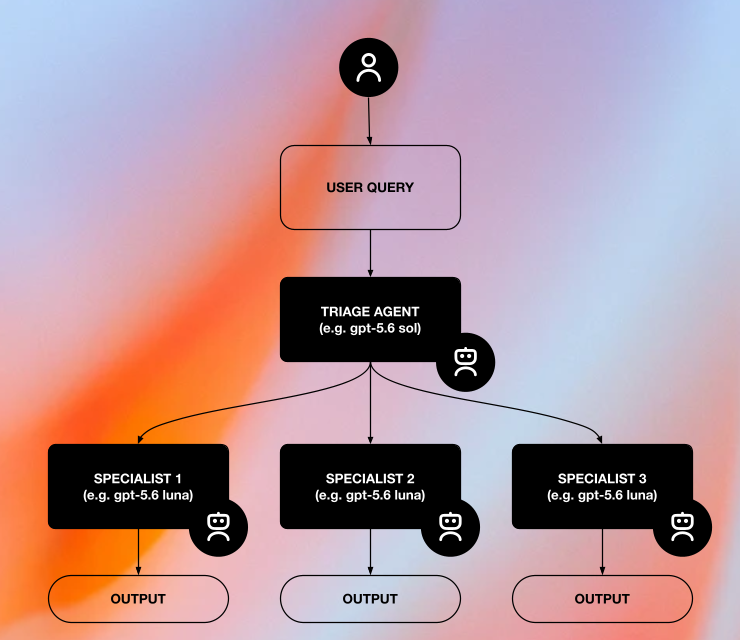

### 그림을 코드로 읽기

| 그림의 구성 요소 | 코드 구현 | 역할 |
| --- | --- | --- |
| User Query | `question` | 응답 언어가 포함된 사용자 요청 |
| Triage Agent | `triage_agent` | 요청에 맞는 전문 Agent를 선택 |
| Specialists | `french_agent`, `spanish_agent`, `english_agent` | 선택된 언어로 응답 |
| Hand-off routes | `triage_agent.handoffs` | 위임 가능한 Agent 목록 |
| Output | `result.final_output` | 선택된 전문 Agent의 최종 응답 |

#### 실행 흐름

1. `Runner.run()`이 요청을 `triage_agent`에 전달합니다.
2. Triage Agent가 요청 언어에 맞는 hand-off 도구를 선택합니다.
3. SDK가 실행 주도권을 선택된 전문 Agent로 넘깁니다.
4. `result.last_agent`와 실행 항목으로 실제 위임을 확인합니다.

#### 그림과 이 예제의 차이

별도의 언어 분류 결과를 먼저 만드는 구조가 아닙니다. Triage Agent가 SDK의 hand-off를 직접 호출하며, 위임 이후에는 전문 Agent가 남은 실행과 최종 응답을 담당합니다.

## 1. 환경 준비

`uv`로 공통 Notebook 환경을 설치한 뒤 해당 커널을 선택하세요. `find_dotenv()`가 현재 위치 또는 상위 디렉터리의 `.env.local`을 찾지만 키 값은 출력하지 않습니다. 기존 환경 변수가 우선합니다.

기본 `RUN_API=False`에서는 Agent 구성과 오프라인 검증만 실행합니다. API 결과를 보려면 다음 셀에서 `RUN_API=True`로 변경하고 아래 셀을 순서대로 실행하세요. 모델 호출 및 웹 검색에는 비용이 발생할 수 있습니다. Notebook에서는 `asyncio.run()` 대신 최상위 `await`를 사용합니다.

In [ ]:
import os

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv

# Look for .env.local in the current working directory and its parents.
env_path = find_dotenv(filename=".env.local", usecwd=True)

if not env_path:
    raise FileNotFoundError(
        "Could not find .env.local in the current directory or any parent directory."
    )

load_dotenv(env_path, override=False)
MODEL = os.getenv("AGENT_MODEL", "gpt-5.6-luna")
RUN_API = False  # Set to True to make real API calls.
set_tracing_disabled(True)  # Disable trace uploads by default for this tutorial.

if RUN_API and not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY in your .env.local file.")

print({"model": MODEL, "api_enabled": RUN_API})

## 2. 전문 Agent와 Triage 정의

`handoffs`에 등록한 Agent에게 제어권이 넘어갑니다. 같은 모델을 사용해도 지침에 따라 역할을 구분할 수 있습니다.

In [ ]:
french_agent = Agent(
    name="French specialist",
    model=MODEL,
    instructions="Reply only in French, in one sentence.",
)

spanish_agent = Agent(
    name="Spanish specialist",
    model=MODEL,
    instructions="Reply only in Spanish, in one sentence.",
)

english_agent = Agent(
    name="English specialist",
    model=MODEL,
    instructions="Reply only in English, in one sentence.",
)

triage_agent = Agent(
    name="Language triage",
    model=MODEL,
    instructions=(
        "Always hand off to the specialist matching the requested response "
        "language. Do not answer yourself."
    ),
    handoffs=[french_agent, spanish_agent, english_agent],
)

question = "Please greet a new student in French."

assert len(triage_agent.handoffs) == 3

## 3. 위임 실행 · API 호출

원본의 대화형 반복을 한 번의 실행으로 줄였습니다.

In [ ]:
result = None

if RUN_API:
    result = await Runner.run(triage_agent, question, max_turns=4)

    print(result.final_output)
else:
    print("API call skipped. Set RUN_API=True to enable it.")

## 4. 실제 위임 확인

응답 언어만 추측하지 않고, handoff 이벤트와 최종 Agent를 확인합니다.

In [ ]:
if result is not None:
    handoffs = [
        item for item in result.new_items if item.type == "handoff_output_item"
    ]

    assert handoffs, "No handoff to a specialist agent occurred."
    assert result.last_agent.name == "French specialist"

    print({"handoffs": len(handoffs), "final_agent": result.last_agent.name})

## 5. 별도 파일로 구성하기: `main()` 실행 진입점

앞의 단계별 실습과 같은 흐름을 하나의 Python 모듈로 구성한 추가 예제입니다. 앞에서 만든 Agent나 전역 변수에 의존하지 않으므로, 공통 실습 패키지가 설치되어 있다면 아래 코드 셀부터 실행할 수 있습니다.

원본처럼 `main()`을 진입점으로 두되, Notebook의 단일 요청 실행 방식을 유지합니다. **Triage Agent가 전문 Agent로 제어권을 넘기고, 전문 Agent가 최종 응답을 작성하는 흐름**을 `route_question()`으로 묶습니다. Python의 조건문으로 언어를 분류하거나 전문 Agent를 직접 호출하는 방식은 아닙니다.

| 구성 | 책임 |
| --- | --- |
| `build_triage_agent()` | 세 언어의 전문 Agent와 handoffs를 가진 Triage Agent 구성 |
| `route_question()` | 요청 실행, 실제 handoff와 최종 담당 Agent 확인, 결과 반환 |
| `main()` | 환경 설정, 실행 여부 결정, 입력 전달과 결과 출력 |

앞의 프랑스어 실습과 달리 재사용 함수는 최종 Agent를 프랑스어로 고정하지 않습니다. 등록된 전문 Agent가 응답했는지 확인하고 그 이름을 반환하므로, 질문을 스페인어·영어로 바꿔도 사용할 수 있습니다. 이 검사는 요청 언어와 응답 언어가 일치하는지까지 평가하지는 않습니다.

기본값은 `run_api=False`입니다. 코드 정의 셀만 실행하면 API를 호출하지 않으며, 실제 호출 여부는 `main(run_api=...)`에서 지정합니다.


In [ ]:
import asyncio
import os

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv


def build_triage_agent(model: str) -> Agent:
    """Create a triage agent and its three language specialists."""
    french_agent = Agent(
        name="French specialist",
        model=model,
        instructions="Reply only in French, in one sentence.",
    )

    spanish_agent = Agent(
        name="Spanish specialist",
        model=model,
        instructions="Reply only in Spanish, in one sentence.",
    )

    english_agent = Agent(
        name="English specialist",
        model=model,
        instructions="Reply only in English, in one sentence.",
    )

    return Agent(
        name="Language triage",
        model=model,
        instructions=(
            "Always hand off to the specialist matching the requested response "
            "language. Do not answer yourself."
        ),
        handoffs=[french_agent, spanish_agent, english_agent],
    )


async def route_question(
    question: str,
    *,
    model: str,
    max_turns: int = 4,
) -> dict:
    """Route one request and return its answer and handoff metadata."""
    triage_agent = build_triage_agent(model)
    result = await Runner.run(
        triage_agent,
        question,
        max_turns=max_turns,
    )

    handoffs = [
        item
        for item in result.new_items
        if item.type == "handoff_output_item"
    ]

    if not handoffs:
        raise RuntimeError("No handoff to a specialist agent occurred.")

    specialist_names = {agent.name for agent in triage_agent.handoffs}

    if result.last_agent.name not in specialist_names:
        raise RuntimeError("The final agent is not a language specialist.")

    answer = str(result.final_output)

    if not answer.strip():
        raise RuntimeError("The specialist returned an empty answer.")

    return {
        "answer": answer,
        "handoffs": len(handoffs),
        "final_agent": result.last_agent.name,
    }


async def main(
    question: str = "Please greet a new student in French.",
    *,
    run_api: bool = False,
    max_turns: int = 4,
) -> dict | None:
    """Load configuration, run language routing, and print its result."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)

    if not env_path:
        raise FileNotFoundError(
            "Could not find .env.local in the current directory "
            "or any parent directory."
        )

    load_dotenv(env_path, override=False)
    model = os.getenv("AGENT_MODEL", "gpt-5.6-luna")
    set_tracing_disabled(True)

    if not run_api:
        print("API call skipped. Pass run_api=True to enable it.")
        return None

    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("Set OPENAI_API_KEY in your .env.local file.")

    result = await route_question(
        question,
        model=model,
        max_turns=max_turns,
    )

    print(result["answer"])
    print({
        "handoffs": result["handoffs"],
        "final_agent": result["final_agent"],
    })

    return result


### Notebook에서 호출하기

Jupyter는 이미 이벤트 루프를 실행하므로 `asyncio.run()` 대신 `await main(...)`을 사용합니다. 아래 셀은 환경 설정을 읽고 API 호출을 생략합니다. `run_api=True`로 바꾸면 비용이 발생하는 새 실행을 시작합니다. 앞의 단계별 실습 결과나 대화 이력을 재사용하지 않습니다.


In [ ]:
standalone_result = await main(
    question="Please greet a new student in French.",
    run_api=False,  # Set to True to run this standalone workflow.
    max_turns=4,
)


### `triage_agent.py` 파일로 실행하기

1. 위의 **함수 정의 코드 셀 전체**를 `triage_agent.py`에 복사합니다. Notebook 전용 `await main(...)` 호출 셀은 복사하지 않습니다.

2. 파일 맨 아래에 다음 진입점을 추가합니다. `--run-api`를 지정한 경우에만 API를 호출합니다.

   ```python
   if __name__ == "__main__":
       import argparse

       parser = argparse.ArgumentParser(description="Route a language request.")
       parser.add_argument("--run-api", action="store_true")
       args = parser.parse_args()

       asyncio.run(main(run_api=args.run_api))
   ```

3. 공통 실습 의존성이 설치된 가상환경을 활성화하고, `.env.local`이 있는 폴더 또는 그 하위에서 실행합니다.

   ```bash
   python triage_agent.py            # Check configuration; skip API calls
   python triage_agent.py --run-api  # Run the workflow; API costs apply
   ```

다른 Python 모듈에서는 `from triage_agent import route_question`으로 가져와 `await route_question(question, model=...)`을 호출할 수 있습니다. 이 경우 환경 변수와 tracing 설정은 호출하는 애플리케이션에서 준비합니다. `if __name__ == "__main__":` 블록 덕분에 import만으로 실행되지 않습니다.

이 추가 예제는 기존 `src/main.py`를 수정하거나 덮어쓰지 않습니다. 파일을 배포할 때는 이 Notebook의 출처와 저장소의 `THIRD_PARTY_NOTICES.md` 고지도 함께 유지하세요.


## 직접 바꿔보기

질문을 스페인어 응답 요청으로 바꾸세요. 마지막 검증의 예상 Agent 이름도 바꾸고, 실제 위임 대상을 확인하세요.

## 원본과 달라진 점 · 주의점

스트리밍·다중 턴 입력 대신 단일 `Runner.run()`을 사용합니다. `handoffs`는 단순 함수 호출과 달리 응답의 담당 Agent를 변경합니다.

## 출처

- [로컬 소스](../src/main.py)
- [OpenAI 공식 예제](https://github.com/openai/openai-agents-python/blob/25af629b3c877ba3d0e95189141bb636b21167a5/examples/agent_patterns/routing.py)
- [Agents SDK 가이드](https://developers.openai.com/api/docs/guides/agents/sdk)
- [Agents 가이드](https://developers.openai.com/api/docs/guides/agents)

이 Notebook은 공식 예제를 학습용으로 재구성한 파일이며 원본의 단순 복사본은 아닙니다. 모델 출력은 실행마다 달라집니다.